<a href="https://colab.research.google.com/github/RefaelBitton/CloudCourse/blob/main/exercise/ex5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
!pip install requests beautifulsoup4
import requests
from bs4 import BeautifulSoup

def fetch_page(url):
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/120.0.0.0 Safari/537.36"
        )
    }



    try:
        response = requests.get(url, headers=headers)
        print("HTTP status:", response.status_code)

        if response.status_code == 200:
            soup = BeautifulSoup(response.text, "html.parser")
            return soup
        else:
            print("Response head:", response.text[:200])
            return None

    except Exception as e:
        print("Request error:", e)
        return None


In [22]:
!pip install firebase

In [23]:
import re
def index_words(soup):
  index = {}
  words = re.findall(r'\w+', soup.get_text())
  for word in words:
    word = word.lower()
    if word in index:
      index[word] += 1
    else:
      index[word] = 1
  return index

In [24]:
def remove_stop_words(index):
  stop_words = {'a', 'an', 'the', 'and', 'or', 'in', 'on', 'at'}
  for stop_word in stop_words:
    if stop_word in index:
      del index[stop_word]
  return index

In [25]:
from nltk.stem import PorterStemmer
def apply_stemming(index):
  stemmer = PorterStemmer()
  stemmed_index = {}
  for word, count in index.items():
    stemmed_word = stemmer.stem(word)
    if stemmed_word in stemmed_index:
      stemmed_index[stemmed_word] += count
    else:
      stemmed_index[stemmed_word] = count
  return stemmed_index

In [26]:
def search(query, index):
  stemmer = PorterStemmer()
  query_words = re.findall(r'\w+', query.lower())
  results = {}
  for word in query_words:
    stemmed_word = stemmer.stem(word)
    if stemmed_word in index:
      results[word] = index[stemmed_word]
  return results

In [27]:
def build_index(url):
  soup = fetch_page(url)
  if soup is None:
     return None
  index = index_words(soup)
  index = remove_stop_words(index)
  index = apply_stemming(index)
  return index


In [28]:
from firebase import firebase
url = 'https://www.barenbrug.co.nz/manage/technologies/grass-diseases'
index = build_index(url)
FBconn = firebase.FirebaseApplication('https://tar6-57edb-default-rtdb.firebaseio.com/', None)
FBconn.post('/myTest1/', index)
print(FBconn.get('/myTest1/', None))


HTTP status: 200
{'-OrhAdpmR9Xlo2nGDK9-': {'2026': 3, 'about': 3, 'acknowledg': 1, 'across': 1, 'action': 1, 'activ': 1, 'ad': 2, 'affect': 3, 'affectedmani': 1, 'affectedperenni': 2, 'affectedryegrass': 7, 'after': 2, 'agricot': 1, 'air': 2, 'all': 6, 'allow': 1, 'also': 4, 'amount': 1, 'ani': 1, 'anim': 6, 'app': 3, 'appear': 4, 'appli': 3, 'april': 1, 'are': 20, 'area': 3, 'arrow': 1, 'articl': 2, 'as': 8, 'autumn': 11, 'avoid': 3, 'back': 1, 'bank': 1, 'bar': 1, 'barenbrug': 12, 'base': 1, 'bay': 1, 'bb': 3, 'be': 6, 'becom': 10, 'befor': 4, 'begin': 1, 'below': 1, 'between': 1, 'black': 1, 'blade': 2, 'blight': 2, 'blightbrown': 1, 'block': 1, 'blotch': 3, 'blotchnet': 1, 'blown': 1, 'blumeria': 1, 'bodi': 1, 'boost': 1, 'born': 4, 'break': 1, 'brick': 1, 'bright': 1, 'brome': 2, 'brown': 10, 'build': 1, 'but': 3, 'buy': 4, 'by': 16, 'calcul': 2, 'calendar': 4, 'can': 18, 'care': 1, 'career': 3, 'carri': 3, 'categori': 1, 'cattl': 1, 'caus': 18, 'causal': 1, 'centr': 1, 'cereal': 

In [29]:
url = 'https://www.barenbrug.co.nz/manage/technologies/grass-diseases'
FBconn = firebase.FirebaseApplication('https://tar6-57edb-default-rtdb.firebaseio.com/', None)
words = ['spread','lines','spore', 'moist','rain','produce','tissue','heat','stress','damping']
dic = {}
result = FBconn.get('/myTest1/', None)
for record_id, data in result.items():
  dic = data
wordToCount = {}
for word in words:
  wordToCount.update(search(word,dic))
print(wordToCount)

{'spread': 8, 'lines': 1, 'spore': 13, 'moist': 3, 'rain': 4, 'produce': 15, 'tissue': 3, 'heat': 1, 'stress': 1, 'damping': 2}


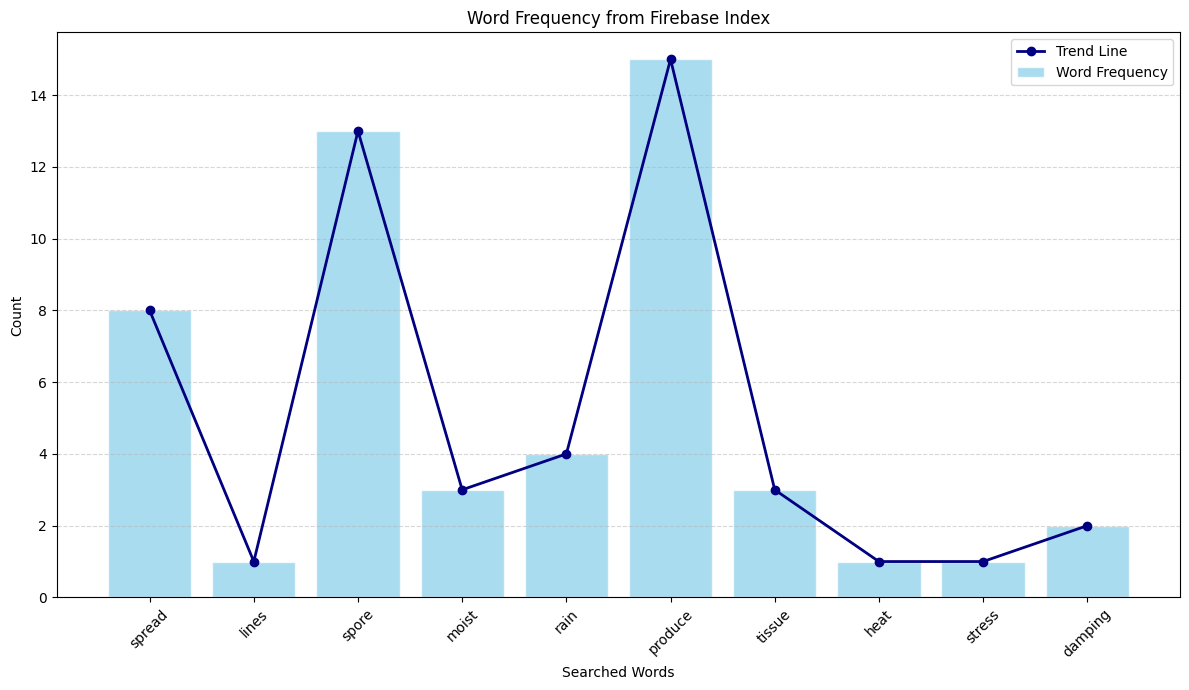

In [30]:
import matplotlib.pyplot as plt

import numpy as np



# Data from the previous cell

words_list = list(wordToCount.keys())

counts_list = list(wordToCount.values())



plt.figure(figsize=(12, 7))

x_pos = np.arange(len(words_list))



# Create bars

bars = plt.bar(x_pos, counts_list, color='skyblue', alpha=0.7, edgecolor='white', label='Word Frequency')



# Add the trend line

plt.plot(x_pos, counts_list, color='navy', marker='o', linewidth=2, label='Trend Line')



plt.title('Word Frequency from Firebase Index')

plt.xlabel('Searched Words')

plt.ylabel('Count')

plt.xticks(x_pos, words_list, rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend()

plt.tight_layout()

plt.show()